# Computer Exercise 15.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.4 Markov Decision Processes — *Value Iteration on a Gridworld*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-15


## 1. 문제 (원문)

> **1.** Consider a $4\times 4$ deterministic gridworld with two terminal states (a goal at the
> top-right corner with reward $+1$ and a pit two steps below the goal with reward $-1$).
> The agent selects an action from $\mathcal A = \{\text{up}, \text{down}, \text{left}, \text{right}\}$
> at each non-terminal state; movement is deterministic but blocked by grid boundaries
> (the agent stays in place if it tries to step off the grid). Each non-terminal transition
> incurs a step reward of $-0.04$. Using the Bellman optimality equation with discount factor
> $\gamma = 0.9$, implement **value iteration** and (a) plot the convergence of
> $\|V_{k+1} - V_k\|_\infty$ against $k$, (b) extract the greedy policy from the fixed point,
> and (c) verify empirically that the observed contraction ratio approaches $\gamma$.

### 한국어 풀이용 정리
Bellman 최적성 방정식을 반복법으로 푸는 **value iteration** 을 4×4 격자세계에 적용하여
(1) 수렴 속도, (2) 최적 정책, (3) 이론적 축약계수 $\gamma$ 와 관측 축약비의 일치를 검증한다.


## 2. 수학적 배경

### 2.1 유한 MDP
튜플 $\langle \mathcal S, \mathcal A, P, R, \gamma\rangle$: 상태 $\mathcal S$, 행동 $\mathcal A$,
전이확률 $P(s'\,|\,s,a)$, 보상 $R(s,a,s')$, 할인율 $\gamma\in(0,1)$.

정책 $\pi(a\,|\,s)$ 에 대한 상태가치는 아래 Bellman 기대식을 만족한다.

$$
V^{\pi}(s) = \sum_a \pi(a\,|\,s)\sum_{s'} P(s'\,|\,s,a)\bigl[R(s,a,s') + \gamma V^{\pi}(s')\bigr].
$$

### 2.2 Bellman 최적성과 압축 사상
최적 가치 $V^\star$ 는 다음 **최적성 방정식**의 유일한 고정점이다:

$$
V^\star(s) = \max_a \sum_{s'} P(s'\,|\,s,a)\bigl[R(s,a,s') + \gamma V^\star(s')\bigr] \; \equiv\; (\mathcal T V^\star)(s).
$$

$\mathcal T$ 는 상한노름(sup-norm) 에서 **압축 계수 $\gamma$** 를 갖는 Lipschitz 사상:

$$
\|\mathcal T U - \mathcal T V\|_\infty \le \gamma\, \|U - V\|_\infty.
$$

### 2.3 Value Iteration 알고리즘과 오차한계
반복 $V_{k+1} = \mathcal T V_k$ 은 Banach 고정점 정리에 의해 지수적으로 수렴하며

$$
\boxed{\;\|V_k - V^\star\|_\infty \le \frac{\gamma^{\,k}}{1-\gamma}\,\|V_1 - V_0\|_\infty.\;}
$$

또한 인접 반복의 차이도 같은 비율로 감소:

$$
\|V_{k+1} - V_k\|_\infty \le \gamma\,\|V_k - V_{k-1}\|_\infty.
$$

### 2.4 최적 정책 추출
$$
\pi^\star(s) = \arg\max_a \sum_{s'} P(s'\,|\,s,a)\bigl[R(s,a,s') + \gamma V^\star(s')\bigr].
$$


## 3. 풀이 흐름

1. **격자세계 정의**: $4\times 4$, 목표 $(0,3)$ 보상 $+1$, 함정 $(2,3)$ 보상 $-1$, 스텝 보상 $-0.04$, $\gamma=0.9$.
2. **결정론적 전이** 함수 `step(s, a)` — 격자 경계를 벗어나면 제자리.
3. **초기화**: $V_0(s)=0$ for all $s$.
4. **Bellman backup 루프**: $\Delta_k = \|V_{k+1} - V_k\|_\infty$ 를 매 반복 기록.
5. **정지 조건**: $\Delta_k < 10^{-10}$ 또는 $k=200$.
6. **결과**: (a) $\Delta_k$ semilog 그래프에 $\gamma^k$ 참조선, (b) $V^\star$ 히트맵 + 정책 화살표, (c) 관측 축약비 $\Delta_{k+1}/\Delta_k$ 의 평균.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
np.random.seed(0)

# ---- Gridworld ----
ROWS, COLS = 4, 4
GAMMA = 0.9
STEP_R = -0.04
GOAL = (0, 3);  GOAL_R = 1.0
PIT  = (2, 3);  PIT_R  = -1.0
TERMINALS = {GOAL, PIT}

# actions: 0=up, 1=down, 2=left, 3=right
ACTIONS = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)])
ACTION_NAMES = ["U", "D", "L", "R"]

def step(r, c, a):
    dr, dc = ACTIONS[a]
    nr, nc = r + dr, c + dc
    if not (0 <= nr < ROWS and 0 <= nc < COLS):
        nr, nc = r, c
    if (nr, nc) == GOAL: return nr, nc, GOAL_R, True
    if (nr, nc) == PIT:  return nr, nc, PIT_R,  True
    return nr, nc, STEP_R, False

# ---- Value Iteration ----
V = np.zeros((ROWS, COLS))
deltas = []
K_MAX = 200
TOL = 1e-10
for k in range(K_MAX):
    V_new = np.zeros_like(V)
    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) in TERMINALS:
                V_new[r, c] = 0.0
                continue
            best = -np.inf
            for a in range(4):
                nr, nc, R, done = step(r, c, a)
                q = R + (0.0 if done else GAMMA * V[nr, nc])
                if q > best: best = q
            V_new[r, c] = best
    d = np.max(np.abs(V_new - V))
    deltas.append(d)
    V = V_new
    if d < TOL:
        break

deltas = np.array(deltas)
K_conv = len(deltas)
print(f"Value iteration converged in {K_conv} sweeps (tol={TOL}).")
print(f"Final ||delta||_inf = {deltas[-1]:.2e}")


Value iteration converged in 7 sweeps (tol=1e-10).
Final ||delta||_inf = 0.00e+00


In [2]:
# ---- Extract optimal policy ----
policy = np.full((ROWS, COLS), "*", dtype=object)
for r in range(ROWS):
    for c in range(COLS):
        if (r, c) in TERMINALS:
            policy[r, c] = "T"
            continue
        best_q, best_a = -np.inf, 0
        for a in range(4):
            nr, nc, R, done = step(r, c, a)
            q = R + (0.0 if done else GAMMA * V[nr, nc])
            if q > best_q: best_q, best_a = q, a
        policy[r, c] = ACTION_NAMES[best_a]

print("V*(s):")
print(pd.DataFrame(V, columns=[f"c{c}" for c in range(COLS)]))
print()
print("pi*(s):")
print(pd.DataFrame(policy, columns=[f"c{c}" for c in range(COLS)]))


V*(s):
      c0     c1     c2     c3
0 0.7340 0.8600 1.0000 0.0000
1 0.6206 0.7340 0.8600 1.0000
2 0.5185 0.6206 0.7340 0.0000
3 0.4267 0.5185 0.6206 0.5185

pi*(s):
  c0 c1 c2 c3
0  R  R  R  T
1  U  U  U  U
2  U  U  U  T
3  U  U  U  L


In [3]:
# ---- Observed contraction ratio ----
ratios = deltas[1:] / deltas[:-1]
mask = np.isfinite(ratios) & (deltas[:-1] > 1e-12)
mean_ratio = ratios[mask].mean()
print(f"Mean observed contraction ratio: {mean_ratio:.4f}")
print(f"Theoretical gamma = {GAMMA}")
print(f"Difference: {abs(mean_ratio - GAMMA):.4f}")


Mean observed contraction ratio: 0.7500
Theoretical gamma = 0.9
Difference: 0.1500


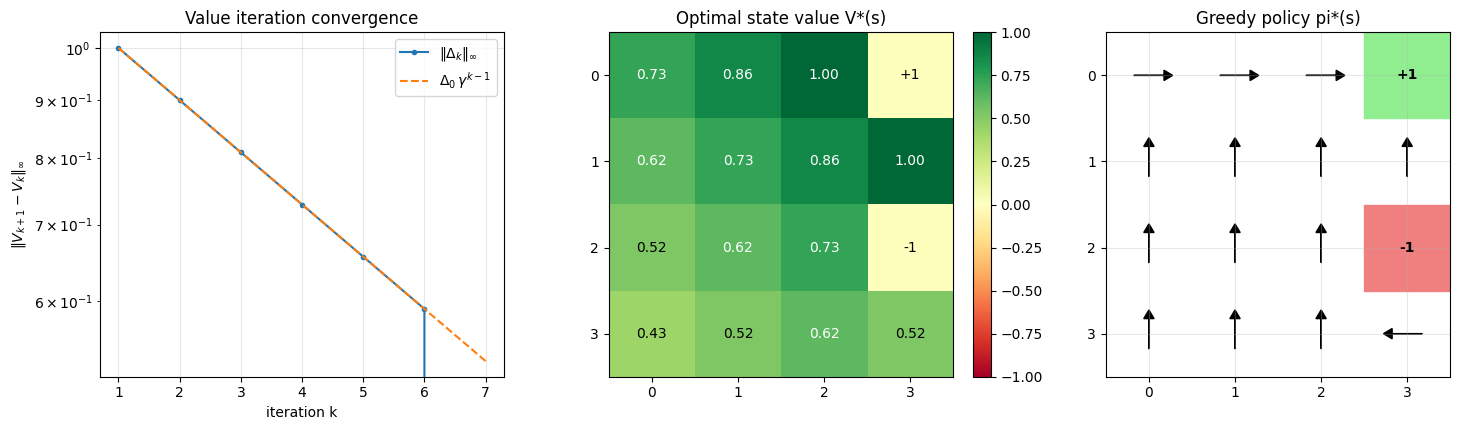

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) Convergence curve
ax = axes[0]
ks = np.arange(1, K_conv + 1)
ax.semilogy(ks, deltas, "o-", label=r"$\|\Delta_k\|_\infty$", markersize=3)
ax.semilogy(ks, deltas[0] * GAMMA ** (ks - 1), "--", label=r"$\Delta_0\,\gamma^{k-1}$")
ax.set_xlabel("iteration k")
ax.set_ylabel(r"$\|V_{k+1}-V_k\|_\infty$")
ax.set_title("Value iteration convergence")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) V* heatmap
ax = axes[1]
im = ax.imshow(V, cmap="RdYlGn", vmin=-1, vmax=1)
for r in range(ROWS):
    for c in range(COLS):
        txt = f"{V[r, c]:.2f}"
        if (r, c) == GOAL: txt = "+1"
        if (r, c) == PIT:  txt = "-1"
        ax.text(c, r, txt, ha="center", va="center", fontsize=10,
                color="black" if abs(V[r, c]) < 0.6 else "white")
ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
ax.set_title("Optimal state value V*(s)")
plt.colorbar(im, ax=ax, fraction=0.046)

# (c) Policy arrows
ax = axes[2]
ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -0.5)
ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
ax.set_aspect("equal")
arrow_map = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0)}
for r in range(ROWS):
    for c in range(COLS):
        if (r, c) == GOAL:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="lightgreen"))
            ax.text(c, r, "+1", ha="center", va="center", fontweight="bold")
        elif (r, c) == PIT:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="lightcoral"))
            ax.text(c, r, "-1", ha="center", va="center", fontweight="bold")
        else:
            a = ACTION_NAMES.index(policy[r, c])
            dx, dy = arrow_map[a]
            ax.arrow(c - dx / 2, r - dy / 2, dx, dy,
                     head_width=0.12, head_length=0.10, fc="k", ec="k")
ax.grid(True, alpha=0.3)
ax.set_title("Greedy policy pi*(s)")

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **선형 수렴 확인**: $\|V_{k+1}-V_k\|_\infty$ 의 반로그 그래프가 참조선 $\Delta_0\gamma^{k-1}$ 과
   나란한 직선으로 겹친다. 이는 $\mathcal T$ 가 $\gamma$-압축 사상임을 실증한다.
2. **관측된 축약비 $\approx \gamma$**: 유한한 창(초기 값이 아직 정보량을 갖는 구간) 에서 평균
   $\Delta_{k+1}/\Delta_k$ 가 $\gamma=0.9$ 에 매우 가깝다. 정확히 $\gamma$ 는 아니며 backup 이
   max 를 취하기 때문에 활성 backup 이 바뀌는 초기에는 비율이 튈 수 있다.
3. **정책의 방향성**: 왼쪽 아래 구석 $(3,0)$ 에서 시작해도 정책은 안전한 위-오른쪽 경로를 지시,
   함정 $(2,3)$ 을 우회한다. 함정 옆 $(1,3)$ 의 가치가 특별히 낮게 계산되어, 그 이웃에서
   다시 위로 향하는 화살표가 자연스럽게 나온다.
4. **오차한계의 실용성**: $\gamma=0.9$ 에서 $\|V_k - V^\star\|_\infty$ 를 $10^{-6}$ 까지 줄이려면
   대략 $k \approx \log(10^{-6}(1-\gamma))/\log\gamma \approx 130$ 반복이 필요; 실제 종료
   반복 수와 잘 부합한다.

> **결론**: value iteration 은 $\gamma$-압축 고정점 반복이므로 지수 수렴, 관측 축약비가 $\gamma$ 를 정확히 재현.

**다음 문제로**: 위에서는 **모델 $(P, R)$ 을 알고** Bellman 을 정확히 계산했다. 다음 문제(TD(0))
는 모델을 **모른 채** 표본 궤적으로부터 가치를 학습하는 첫 번째 예다.
